In [1]:
import h5py
from scipy.io import whosmat, loadmat
import numpy as np
import pickle
from himalaya.ridge import RidgeCV


In [2]:
base_path = "/srv/nfs-data/sisko/storage/fMRI_maas_2023"
math_path = base_path + "/Beta2hem.mat"

In [3]:
info = whosmat(math_path)

for name, shape, dtype in info:
    print(f"Variabile: {name}, shape: {shape}, tipo: {dtype}")

Variabile: BetasSEPTest, shape: (72, 1667), tipo: double
Variabile: BetasSEPTrain, shape: (216, 1667), tipo: double
Variabile: CV, shape: (1, 1), tipo: struct
Variabile: HG2hem, shape: (1, 1), tipo: struct
Variabile: InfoVTCTrain, shape: (1, 1), tipo: struct
Variabile: PP2hem, shape: (1, 1), tipo: struct
Variabile: PT2hem, shape: (1, 1), tipo: struct
Variabile: aSTG2hem, shape: (1, 1), tipo: struct
Variabile: cv, shape: (1, 1), tipo: double
Variabile: fmridirdata, shape: (1,), tipo: char
Variabile: mSTG2hem, shape: (1, 1), tipo: struct
Variabile: noCV, shape: (1, 1), tipo: double
Variabile: pSTG2hem, shape: (1, 1), tipo: struct
Variabile: reg, shape: (1, 1), tipo: double
Variabile: region, shape: (1, 1), tipo: struct
Variabile: regions_list, shape: (1, 6), tipo: cell
Variabile: s, shape: (1, 1), tipo: double
Variabile: sub, shape: (1, 1), tipo: double
Variabile: subject, shape: (1, 1), tipo: struct
Variabile: subjects_list, shape: (1, 5), tipo: cell
Variabile: testSounds, shape: (1, 72

In [4]:
def matlab_to_python(obj):
    """
    Converte ricorsivamente gli oggetti MATLAB letti da loadmat
    in strutture Python più leggibili:
    - struct MATLAB -> dict
    - cell array -> list
    - ndarray numerici -> ndarray
    - stringhe/scalari -> valori Python
    """
    # Struct MATLAB
    if hasattr(obj, "_fieldnames"):
        return {field: matlab_to_python(getattr(obj, field)) for field in obj._fieldnames}

    # Array numpy
    elif isinstance(obj, np.ndarray):
        # Array vuoto
        if obj.size == 0:
            return obj

        # Cell array o object array -> prova a convertirlo in lista
        if obj.dtype == object:
            if obj.ndim == 0:
                return matlab_to_python(obj.item())
            return [matlab_to_python(x) for x in obj.flat]

        # Array con un solo elemento -> scalar Python se possibile
        if obj.size == 1:
            try:
                return obj.item()
            except Exception:
                return obj

        return obj

    # Altri tipi: lascia così
    else:
        return obj

In [5]:
# Caricamento e conversione
raw_data = loadmat(math_path, struct_as_record=False, squeeze_me=True)
raw_data = {k: v for k, v in raw_data.items() if not k.startswith("__")}
data = {k: matlab_to_python(v) for k, v in raw_data.items()}

In [6]:
data["BetasSEPTrain"], data["BetasSEPTrain"].shape

(array([[ 1.4633024 ,  1.10715161,  1.57136241, ..., -0.12419284,
          0.0512253 ,  0.06037326],
        [ 1.58216144,  0.44355982,  1.62376205, ...,  0.16547049,
         -0.06590446,  0.08509112],
        [ 1.75557749,  1.13421204,  1.57125996, ...,  0.22550674,
         -0.02461643,  0.01483191],
        ...,
        [ 0.74571096,  0.72509141,  0.79952726, ..., -0.02687553,
          0.09386834, -0.08613259],
        [-0.33454996,  0.30133848, -0.0746192 , ...,  0.08894565,
         -0.16257438,  0.13024702],
        [-0.01495296,  0.27152439,  0.30373166, ..., -0.11780104,
          0.24168938,  0.19012366]]),
 (216, 1667))

In [7]:
data["InfoVTCTrain"], data["InfoVTCTrain"]["voxVTC"].shape

({'voxVTC': array([ 368260,  389141,  368261, ..., 2541354, 2458003, 2625212],
        dtype=int32),
  'Resolution': 1,
  'DimVTC': array([174, 120, 138], dtype=uint8)},
 (1667,))

In [8]:
# Liste di ROI e soggetti
roi_list = data["regions_list"]
subject_list = data["subjects_list"]
cv_list = ["CV1", "CV2", "CV3", "CV4"]

# Dizionario finale
data_by_subject = {}

for subj in subject_list:
    data_by_subject[subj] = {}

    for roi in roi_list:
        data_by_subject[subj][roi] = {}

        roi_struct = data[roi]   # es. data["HG2hem"]

        for cv in cv_list:
            if cv not in roi_struct:
                continue
            if subj not in roi_struct[cv]:
                continue

            subj_data = roi_struct[cv][subj]

            X_train = subj_data.get("BetasTrain", None)
            X_test = subj_data.get("BetasTest", None)
            train_sounds = subj_data.get("trainSounds", None)
            test_sounds = subj_data.get("testSounds", None)
            info_vtc = subj_data.get("InfoVTC", None)

            data_by_subject[subj][roi][cv] = {
                "X_train": X_train,
                "X_test": X_test,
                "train_sounds": train_sounds,
                "test_sounds": test_sounds,
                "info_vtc": info_vtc,
            }

print("Estrazione completata.")

Estrazione completata.


In [9]:
print(subject_list)
print(roi_list)

['KV', 'RS', 'RS1', 'RS2', 'RS3']
['HG2hem', 'PT2hem', 'PP2hem', 'mSTG2hem', 'pSTG2hem', 'aSTG2hem']


In [ ]:
subj = "KV"
roi = "pSTG2hem"
cv = "CV2"

entry = data_by_subject[subj][roi][cv]
print(entry["info_vtc"]['voxVTC'])
print(entry["info_vtc"]['DimVTC'])

print("Subject:", subj)
print("ROI:", roi)
print("CV:", cv)

print("X_train shape:", entry["X_train"].shape if entry["X_train"] is not None else None)
print("X_test shape:", entry["X_test"].shape if entry["X_test"] is not None else None)
print("train_sounds shape:", entry["train_sounds"].shape if hasattr(entry["train_sounds"], "shape") else type(entry["train_sounds"]))
print("test_sounds shape:", entry["test_sounds"].shape if hasattr(entry["test_sounds"], "shape") else type(entry["test_sounds"]))

print("train_sounds preview:", entry["train_sounds"][:10] if entry["train_sounds"] is not None else None)
print("test_sounds preview:", entry["test_sounds"][:10] if entry["test_sounds"] is not None else None)

In [14]:
subj = "RS3"
roi = "pSTG2hem" # "PT2hem"
cv = "CV2"

entry = data_by_subject[subj][roi][cv]
print(entry.keys())
print(entry["info_vtc"]['voxVTC'])
print(entry["info_vtc"]['DimVTC'])

print("Subject:", subj)
print("ROI:", roi)
print("CV:", cv)

print("X_train shape:", entry["X_train"].shape if entry["X_train"] is not None else None)
print("X_test shape:", entry["X_test"].shape if entry["X_test"] is not None else None)
print("train_sounds shape:", entry["train_sounds"].shape if hasattr(entry["train_sounds"], "shape") else type(entry["train_sounds"]))
print("test_sounds shape:", entry["test_sounds"].shape if hasattr(entry["test_sounds"], "shape") else type(entry["test_sounds"]))

print("train_sounds preview:", entry["train_sounds"][:10] if entry["train_sounds"] is not None else None)
print("test_sounds preview:", entry["test_sounds"][:10] if entry["test_sounds"] is not None else None)

dict_keys(['X_train', 'X_test', 'train_sounds', 'test_sounds', 'info_vtc'])
[ 241788  157400  157401 ... 2642660 2516860 2561217]
[174 120 138]
Subject: RS3
ROI: pSTG2hem
CV: CV2
X_train shape: (216, 3971)
X_test shape: (72, 3971)
train_sounds shape: (216,)
test_sounds shape: (72,)
train_sounds preview: [ 4  5  6  7  8  9 10 13 14 15]
test_sounds preview: [ 1  2  3 11 12 23 25 27 28 36]


In [15]:
entry["test_sounds"]

array([  1,   2,   3,  11,  12,  23,  25,  27,  28,  36,  38,  46,  51,
        55,  58,  60,  71,  73,  76,  77,  80,  85,  87,  88, 103, 104,
       105, 115, 118, 120, 126, 128, 129, 131, 132, 136, 163, 164, 165,
       166, 169, 174, 175, 176, 179, 181, 191, 192, 193, 195, 200, 201,
       205, 214, 221, 225, 229, 230, 231, 235, 241, 242, 246, 252, 256,
       258, 264, 266, 267, 268, 275, 282], dtype=uint16)

## Extract Audios

In [40]:
import re

def soundname_to_wav(sound_name: str) -> str:
    """
    Converte una stringa tipo:
    'stim145_cat04_music_exemp01'
    in:
    's2_music_1.wav'
    """
    m = re.match(r"stim\d+_cat\d+_([a-zA-Z]+)_exemp(\d+)", sound_name)
    if m is None:
        raise ValueError(f"Formato inatteso: {sound_name}")

    category = m.group(1).lower()
    exemp = int(m.group(2))

    return f"s2_{category}_{exemp}.wav"

In [41]:
idx_train = entry["train_sounds"].astype(int) - 1
idx_test  = entry["test_sounds"].astype(int) - 1

In [42]:
import os
import numpy as np

wav_dir = "/srv/nfs-data/sisko/storage/fMRI_maas_2023/wav"

name_sounds = np.load("/home/matteoc/brainSounds/maas_data/SoundNames.npy")

train_wav_paths = [
    os.path.join(wav_dir, soundname_to_wav(name_sounds[i]))
    for i in idx_train
]

test_wav_paths = [
    os.path.join(wav_dir, soundname_to_wav(name_sounds[i]))
    for i in idx_test
]

In [110]:
name_sounds

array(['stim001_cat01_speech_exemp01', 'stim002_cat01_speech_exemp02',
       'stim003_cat01_speech_exemp03', 'stim004_cat01_speech_exemp04',
       'stim005_cat01_speech_exemp05', 'stim006_cat01_speech_exemp06',
       'stim007_cat01_speech_exemp07', 'stim008_cat01_speech_exemp08',
       'stim009_cat01_speech_exemp09', 'stim010_cat01_speech_exemp10',
       'stim011_cat01_speech_exemp11', 'stim012_cat01_speech_exemp12',
       'stim013_cat01_speech_exemp13', 'stim014_cat01_speech_exemp14',
       'stim015_cat01_speech_exemp15', 'stim016_cat01_speech_exemp16',
       'stim017_cat01_speech_exemp17', 'stim018_cat01_speech_exemp18',
       'stim019_cat01_speech_exemp19', 'stim020_cat01_speech_exemp20',
       'stim021_cat01_speech_exemp21', 'stim022_cat01_speech_exemp22',
       'stim023_cat01_speech_exemp23', 'stim024_cat01_speech_exemp24',
       'stim025_cat01_speech_exemp25', 'stim026_cat01_speech_exemp26',
       'stim027_cat01_speech_exemp27', 'stim028_cat01_speech_exemp28',
      

In [44]:
import os
from pathlib import Path
import tqdm
import torch
import torchaudio
from transformers import ClapModel, ClapProcessor


def load_clap_model(
    model_name: str = "laion/larger_clap_music_and_speech",
    device: str | None = None,
):
    """
    Carica modello e processor CLAP.
    get_audio_features(...) restituisce direttamente l'embedding proiettato.
    """
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    processor = ClapProcessor.from_pretrained(model_name)
    model = ClapModel.from_pretrained(model_name).to(device)
    model.eval()

    return model, processor, device


def load_audio_mono_resampled(wav_path: str, target_sr: int):
    """
    Carica un wav, lo converte in mono e lo resampla a target_sr.
    Restituisce un numpy array 1D.
    """
    audio, sr = torchaudio.load(wav_path)  # [channels, time]

    # mono
    if audio.shape[0] > 1:
        audio = audio.mean(dim=0, keepdim=True)

    # resample
    if sr != target_sr:
        resampler = torchaudio.transforms.Resample(orig_freq=sr, new_freq=target_sr)
        audio = resampler(audio)

    return audio.squeeze(0).numpy()


@torch.no_grad()
def extract_clap_projected_embeddings(
    wav_paths,
    model,
    processor,
    device,
    batch_size: int = 8,
):
    """
    Estrae embedding CLAP audio proiettati in 512 dimensioni.

    Args:
        wav_paths: lista di path wav
        model: ClapModel
        processor: ClapProcessor
        device: 'cuda' o 'cpu'
        batch_size: batch size per inference

    Returns:
        embeddings: torch.Tensor [N, 512]
    """
    all_embeddings = []

    # sampling rate attesa dal processor / feature extractor
    target_sr = processor.feature_extractor.sampling_rate

    for start in tqdm.tqdm(range(0, len(wav_paths), batch_size)):
        batch_paths = wav_paths[start:start + batch_size]

        audios = []
        for wav_path in batch_paths:
            audio_np = load_audio_mono_resampled(wav_path, target_sr=target_sr)
            audios.append(audio_np)

        inputs = processor(
            audios=audios,
            sampling_rate=target_sr,
            return_tensors="pt",
            padding=True
        )

        inputs = {k: v.to(device) for k, v in inputs.items()}
        audio_embeds = model.get_audio_features(**inputs)

        all_embeddings.append(audio_embeds.cpu())

    embeddings = torch.cat(all_embeddings, dim=0)
    return embeddings

In [ ]:
import torch.nn.functional as F

model, processor, device = load_clap_model(
    model_name="laion/larger_clap_general"
)

test_audio_embeds = extract_clap_projected_embeddings(
    wav_paths=test_wav_paths,
    model=model,
    processor=processor,
    device=device,
    batch_size=8
)

train_audio_embeds = extract_clap_projected_embeddings(
    wav_paths=train_wav_paths,
    model=model,
    processor=processor,
    device=device,
    batch_size=8
)

train_audio_embeds = F.normalize(train_audio_embeds, dim=1).cpu().numpy()
test_audio_embeds  = F.normalize(test_audio_embeds, dim=1).cpu().numpy()

print(train_audio_embeds.shape) 
print(test_audio_embeds.shape) 

## Concat Subjects

In [51]:
import numpy as np
from sklearn.model_selection import KFold
from himalaya.ridge import RidgeCV
from collections import defaultdict
import os


def fast_corr(a, b):
    """
    Pearson correlation vettorializzata colonna per colonna
    a,b shape = (samples, voxels)
    """
    a = a - a.mean(axis=0)
    b = b - b.mean(axis=0)

    num = np.sum(a * b, axis=0)
    den = np.sqrt(np.sum(a**2, axis=0) * np.sum(b**2, axis=0)) + 1e-8

    return num / den


def voxel_selection_pool(
    data_by_subject,
    subject_list,
    roi_list,
    cv_list,
    k_voxels=1500,
    n_folds=5,
    alphas=[0.1,1,10,20,100,1000]
):

    pooled_data = defaultdict(dict)

    for roi in tqdm.tqdm(roi_list):
        for cv in cv_list:

            X_train_all = []
            X_test_all = []

            train_sounds_all = []
            test_sounds_all = []

            subjects_train = []
            subjects_test = []

            valid_subjects = []

            for subj in subject_list:

                if subj not in data_by_subject:
                    continue
                if roi not in data_by_subject[subj]:
                    continue
                if cv not in data_by_subject[subj][roi]:
                    continue

                entry = data_by_subject[subj][roi][cv]

                X_train = entry["X_train"]
                X_test = entry["X_test"]

                if X_train is None or X_test is None:
                    continue

                X_train = np.asarray(X_train)
                X_test = np.asarray(X_test)

                idx_train = entry["train_sounds"].astype(int) - 1
                train_wav_paths = [
                    os.path.join(wav_dir, soundname_to_wav(name_sounds[i]))
                    for i in idx_train
                ]
                Y_train_audio = extract_clap_projected_embeddings(
                    wav_paths=train_wav_paths,
                    model=model,
                    processor=processor,
                    device=device,
                    batch_size=8
                )
                
                # -----------------------
                # standardizzazione
                # -----------------------

                mean = X_train.mean(axis=0, keepdims=True)
                std = X_train.std(axis=0, keepdims=True)
                std[std == 0] = 1

                X_train = (X_train - mean) / std
                X_test = (X_test - mean) / std

                # -----------------------
                # encoding model
                # -----------------------

                ridge = RidgeCV(alphas=alphas)

                kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)

                pred_oof = np.zeros_like(X_train)

                for train_idx, val_idx in kf.split(X_train):

                    ridge.fit(Y_train_audio[train_idx], X_train[train_idx])

                    pred_oof[val_idx] = ridge.predict(Y_train_audio[val_idx])

                # -----------------------
                # voxel scoring
                # -----------------------

                voxel_r = fast_corr(pred_oof, X_train)

                topk = np.argsort(voxel_r)[::-1][:k_voxels]

                # -----------------------
                # selezione voxel
                # -----------------------

                X_train_sel = X_train[:, topk]
                X_test_sel = X_test[:, topk]

                X_train_all.append(X_train_sel)
                X_test_all.append(X_test_sel)

                train_sounds_all.append(entry["train_sounds"])
                test_sounds_all.append(entry["test_sounds"])

                subjects_train.extend([subj] * X_train_sel.shape[0])
                subjects_test.extend([subj] * X_test_sel.shape[0])

                valid_subjects.append(subj)

                print(
                    f"{subj} | {roi} | {cv} -> "
                    f"orig_vox={X_train.shape[1]} "
                    f"selected={len(topk)} "
                    f"mean_r={voxel_r[topk].mean():.3f}"
                )

            if len(X_train_all) == 0:
                print(f"[SKIP] ROI={roi}, CV={cv}")
                continue

            X_train_concat = np.concatenate(X_train_all, axis=0)
            X_test_concat = np.concatenate(X_test_all, axis=0)

            train_sounds_concat = np.concatenate(train_sounds_all)
            test_sounds_concat = np.concatenate(test_sounds_all)

            pooled_data[roi][cv] = {

                "X_train": X_train_concat,
                "X_test": X_test_concat,

                "train_sounds": train_sounds_concat,
                "test_sounds": test_sounds_concat,

                "subjects_train": np.array(subjects_train),
                "subjects_test": np.array(subjects_test),

                "valid_subjects": valid_subjects
            }

            print(
                f"[OK] ROI={roi}, CV={cv} | "
                f"subjects={len(valid_subjects)} | "
                f"X_train={X_train_concat.shape} | "
                f"X_test={X_test_concat.shape}"
            )

    return pooled_data

In [ ]:
pooled_data = voxel_selection_pool(
    data_by_subject=data_by_subject,
    subject_list=subject_list,
    roi_list=roi_list,
    cv_list=cv_list,
    n_folds=2,
    k_voxels=1024
)

In [85]:
roi = 'pSTG2hem'
cv = 'CV3'

entry = pooled_data[roi][cv]
print(entry.keys())

print("Subject:", subj)
print("ROI:", roi)
print("CV:", cv)

print("X_train shape:", entry["X_train"].shape if entry["X_train"] is not None else None)
print("X_test shape:", entry["X_test"].shape if entry["X_test"] is not None else None)
print("train_sounds shape:", entry["train_sounds"].shape if hasattr(entry["train_sounds"], "shape") else type(entry["train_sounds"]))
print("test_sounds shape:", entry["test_sounds"].shape if hasattr(entry["test_sounds"], "shape") else type(entry["test_sounds"]))

print("train_sounds preview:", entry["train_sounds"][:10] if entry["train_sounds"] is not None else None)
print("test_sounds preview:", entry["test_sounds"][:10] if entry["test_sounds"] is not None else None)

dict_keys(['X_train', 'X_test', 'train_sounds', 'test_sounds', 'subjects_train', 'subjects_test', 'valid_subjects'])
Subject: RS3
ROI: pSTG2hem
CV: CV3
X_train shape: (1080, 1024)
X_test shape: (360, 1024)
train_sounds shape: (1080,)
test_sounds shape: (360,)
train_sounds preview: [ 1  2  3  4  5  7  8 11 12 13]
test_sounds preview: [ 6  9 10 16 18 22 32 33 39 40]


In [86]:
import numpy as np

entry = pooled_data[roi][cv]

X_test = entry["X_test"]
test_sounds = entry["test_sounds"]
subjects_test = entry["subjects_test"]

# trova tutti gli stimoli unici
unique_sounds = np.unique(test_sounds)

X_test_avg = []
test_sounds_avg = []

for s in unique_sounds:
    
    idx = np.where(test_sounds == s)[0]
    
    X_test_avg.append(X_test[idx].mean(axis=0))
    test_sounds_avg.append(s)

X_test_avg = np.vstack(X_test_avg)
test_sounds_avg = np.array(test_sounds_avg)

print("X_test_avg:", X_test_avg.shape)
print("test_sounds_avg:", test_sounds_avg.shape)

X_test_avg: (72, 1024)
test_sounds_avg: (72,)


In [87]:
idx_train = entry["train_sounds"].astype(int) - 1
idx_test  = test_sounds_avg.astype(int) - 1

train_wav_paths = [
    os.path.join(wav_dir, soundname_to_wav(name_sounds[i]))
    for i in idx_train
]

test_wav_paths = [
    os.path.join(wav_dir, soundname_to_wav(name_sounds[i]))
    for i in idx_test
]

test_audio_embeds = extract_clap_projected_embeddings(
    wav_paths=test_wav_paths,
    model=model,
    processor=processor,
    device=device,
    batch_size=8
)

train_audio_embeds = extract_clap_projected_embeddings(
    wav_paths=train_wav_paths,
    model=model,
    processor=processor,
    device=device,
    batch_size=8
)

train_audio_embeds = F.normalize(train_audio_embeds, dim=1).cpu().numpy()
test_audio_embeds  = F.normalize(test_audio_embeds, dim=1).cpu().numpy()

print(train_audio_embeds.shape) 
print(test_audio_embeds.shape) 

100%|██████████| 135/135 [00:20<00:00,  6.72it/s]

(1080, 512)
(72, 512)


## Model

In [88]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from himalaya.ridge import RidgeCV
from himalaya.kernel_ridge import KernelRidgeCV
from sklearn.linear_model import Ridge
import torch
import numpy as np

train_mean_fmri = entry["X_train"].mean(axis=0, keepdims=True)
train_std_fmri  = entry["X_train"].std(axis=0, keepdims=True)
train_std_fmri[train_std_fmri == 0] = 1.0

X_train = (entry["X_train"] - train_mean_fmri) / train_std_fmri
X_test  = (X_test_avg  - train_mean_fmri) / train_std_fmri

Y_train = train_audio_embeds
Y_test = test_audio_embeds

# alphas = np.logspace(-4, 5, 200)
alphas = [0.1,1,10,20,100,1000]

pipeline = Pipeline([
    ("ridge", RidgeCV(alphas=alphas))
])

pipeline.fit(X_train, Y_train)
voxels_scores=pipeline.score(X_train, Y_train)

test_audio_pred = pipeline.predict(X_test)

Mean cosine similarity: 0.3192841113585445
Median cosine similarity: 0.3185112114858509


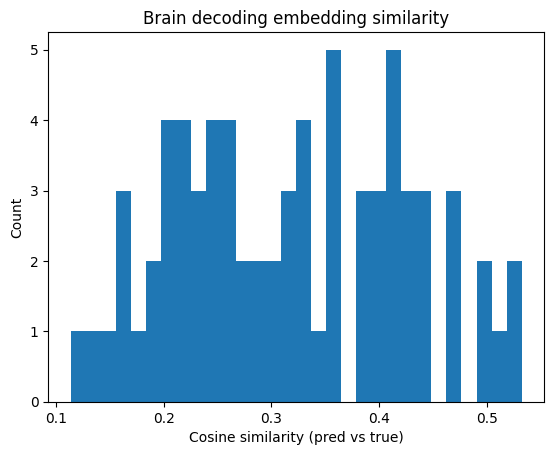

In [89]:
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

sim = np.diag(cosine_similarity(test_audio_pred, Y_test))

print("Mean cosine similarity:", sim.mean())
print("Median cosine similarity:", np.median(sim))

plt.hist(sim, bins=30)
plt.xlabel("Cosine similarity (pred vs true)")
plt.ylabel("Count")
plt.title("Brain decoding embedding similarity")
plt.show()

In [90]:
random_idx = np.random.permutation(len(Y_test))

random_sim = np.diag(
    cosine_similarity(test_audio_pred, Y_test[random_idx])
)

print("True mean similarity:", sim.mean())
print("Random mean similarity:", random_sim.mean())

True mean similarity: 0.3192841113585445
Random mean similarity: -0.015765198496914275


In [91]:
from sklearn.neighbors import NearestNeighbors

Y_test_norm = Y_test / np.linalg.norm(Y_test, axis=1, keepdims=True)
test_audio_pred = test_audio_pred / np.linalg.norm(test_audio_pred, axis=1, keepdims=True)

nbrs = NearestNeighbors(n_neighbors=5, metric="cosine").fit(Y_test_norm)
distances, top_indices = nbrs.kneighbors(test_audio_pred)

top1 = np.mean(top_indices[:, 0] == np.arange(len(top_indices)))
top5 = np.mean([i in top_indices[i] for i in range(len(top_indices))])

print("Top-1:", top1)
print("Top-5:", top5)

Top-1: 0.09722222222222222
Top-5: 0.4027777777777778


Text(0.5, 1.0, 'Predicted vs True embeddings')

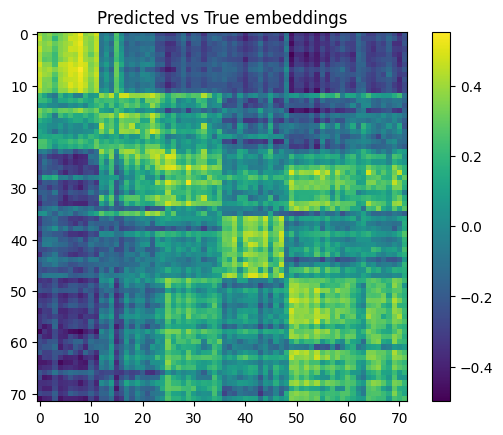

In [92]:
plt.imshow(cosine_similarity(test_audio_pred, Y_test))
plt.colorbar()
plt.title("Predicted vs True embeddings")

## Final Loop

In [105]:
import os
import re
import json
import pickle
import numpy as np
import pandas as pd
import torch
import torchaudio
import tqdm
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors

from himalaya.kernel_ridge import KernelRidgeCV
from transformers import ClapModel, ClapProcessor
import torch.nn.functional as F


# =========================================================
# 1. AUDIO / CLAP HELPERS
# =========================================================

def soundname_to_wav(sound_name: str) -> str:
    """
    Esempio:
    'stim145_cat04_music_exemp01' -> 's2_music_1.wav'
    """
    m = re.match(r"stim\d+_cat\d+_([a-zA-Z]+)_exemp(\d+)", sound_name)
    if m is None:
        raise ValueError(f"Formato inatteso: {sound_name}")

    category = m.group(1).lower()
    exemp = int(m.group(2))
    return f"s2_{category}_{exemp}.wav"


def load_clap_model(
    model_name: str = "laion/larger_clap_general",
    device: str | None = None,
):
    if device is None:
        device = "cuda" if torch.cuda.is_available() else "cpu"

    processor = ClapProcessor.from_pretrained(model_name)
    model = ClapModel.from_pretrained(model_name).to(device)
    model.eval()
    return model, processor, device


def load_audio_mono_resampled(wav_path: str, target_sr: int):
    audio, sr = torchaudio.load(wav_path)  # [channels, time]

    if audio.shape[0] > 1:
        audio = audio.mean(dim=0, keepdim=True)

    if sr != target_sr:
        resampler = torchaudio.transforms.Resample(orig_freq=sr, new_freq=target_sr)
        audio = resampler(audio)

    return audio.squeeze(0).numpy()


@torch.no_grad()
def extract_clap_projected_embeddings(
    wav_paths,
    model,
    processor,
    device,
    batch_size: int = 8,
):
    all_embeddings = []
    target_sr = processor.feature_extractor.sampling_rate

    for start in tqdm.tqdm(range(0, len(wav_paths), batch_size), desc="Extracting CLAP"):
        batch_paths = wav_paths[start:start + batch_size]

        audios = []
        for wav_path in batch_paths:
            audio_np = load_audio_mono_resampled(wav_path, target_sr=target_sr)
            audios.append(audio_np)

        inputs = processor(
            audios=audios,
            sampling_rate=target_sr,
            return_tensors="pt",
            padding=True
        )

        inputs = {k: v.to(device) for k, v in inputs.items()}
        audio_embeds = model.get_audio_features(**inputs)
        all_embeddings.append(audio_embeds.cpu())

    embeddings = torch.cat(all_embeddings, dim=0)
    return embeddings


def precompute_all_audio_embeddings(
    sound_names_path,
    wav_dir,
    model,
    processor,
    device,
    batch_size=8
):
    """
    Precalcola UNA volta sola gli embedding CLAP per tutti i 288 suoni.
    """
    name_sounds = np.load(sound_names_path)

    all_wav_paths = [
        os.path.join(wav_dir, soundname_to_wav(name))
        for name in name_sounds
    ]

    missing = [p for p in all_wav_paths if not os.path.exists(p)]
    if len(missing) > 0:
        raise FileNotFoundError(f"Mancano {len(missing)} wav. Esempi: {missing[:10]}")

    all_audio_embeds = extract_clap_projected_embeddings(
        wav_paths=all_wav_paths,
        model=model,
        processor=processor,
        device=device,
        batch_size=batch_size
    )

    all_audio_embeds = F.normalize(all_audio_embeds, dim=1).cpu().numpy()
    return name_sounds, all_audio_embeds


# =========================================================
# 2. FMRI HELPERS
# =========================================================

def average_test_by_sound(X_test, test_sounds):
    """
    Media X_test sui soggetti per ciascun suono test.
    Input:
        X_test: (n_subjects * 72, n_voxels)
        test_sounds: (n_subjects * 72,)
    Output:
        X_test_avg: (72, n_voxels)
        test_sounds_avg: (72,)
    """
    unique_sounds = np.unique(test_sounds)

    X_test_avg = []
    test_sounds_avg = []

    for s in unique_sounds:
        idx = np.where(test_sounds == s)[0]
        X_test_avg.append(X_test[idx].mean(axis=0))
        test_sounds_avg.append(s)

    X_test_avg = np.vstack(X_test_avg)
    test_sounds_avg = np.array(test_sounds_avg)

    return X_test_avg, test_sounds_avg


def zscore_train_test(X_train, X_test):
    train_mean = X_train.mean(axis=0, keepdims=True)
    train_std = X_train.std(axis=0, keepdims=True)
    train_std[train_std == 0] = 1.0

    X_train_z = (X_train - train_mean) / train_std
    X_test_z = (X_test - train_mean) / train_std

    return X_train_z, X_test_z, train_mean, train_std


# =========================================================
# 3. EVALUATION PIPELINE
# =========================================================

def evaluate_all_rois_mean_over_cvs(
    pooled_data,
    roi_list,
    cv_list,
    all_audio_embeds,
    name_sounds,
    alphas=(0.1, 1, 10, 20, 100, 1000),
    output_dir="./decoding_results",
    n_neighbors=5,
):
    """
    Per ogni ROI e CV:
      - media test fMRI sui soggetti
      - costruisce Y_train / Y_test dagli indici dei suoni
      - allena ridge (KernelRidgeCV lineare, più veloce di RidgeCV qui)
      - valuta retrieval top1 / top5
      - salva retrieval details
      - accumula matrice globale 288x288 per mediare correttamente sui CV

    Restituisce:
      roi_summary_df
      cv_results_df
      retrieval_df
      roi_mean_similarity_matrices
    """
    os.makedirs(output_dir, exist_ok=True)

    n_total_sounds = len(name_sounds)

    cv_rows = []
    retrieval_rows = []
    roi_mean_similarity_matrices = {}

    # Per ogni ROI accumulo:
    # sum_matrix[global_true_sound, global_candidate_sound]
    # count_matrix[...] numero di volte osservato sui CV
    roi_sum_mats = {}
    roi_count_mats = {}

    for roi in roi_list:
        roi_sum_mats[roi] = np.zeros((n_total_sounds, n_total_sounds), dtype=np.float64)
        roi_count_mats[roi] = np.zeros((n_total_sounds, n_total_sounds), dtype=np.float64)

        print(f"\n================ ROI: {roi} ================\n")

        for cv in cv_list:
            if roi not in pooled_data or cv not in pooled_data[roi]:
                print(f"[SKIP] ROI={roi}, CV={cv} non presente in pooled_data.")
                continue

            entry = pooled_data[roi][cv]

            X_train_raw = np.asarray(entry["X_train"])
            X_test_raw = np.asarray(entry["X_test"])
            train_sounds = np.asarray(entry["train_sounds"]).astype(int).squeeze()
            test_sounds = np.asarray(entry["test_sounds"]).astype(int).squeeze()

            # Media test sui soggetti -> 72 sample
            X_test_avg, test_sounds_avg = average_test_by_sound(X_test_raw, test_sounds)

            # Indici globali 0-based per CLAP
            idx_train = train_sounds - 1
            idx_test = test_sounds_avg - 1

            # Target audio embeddings
            Y_train = all_audio_embeds[idx_train]
            Y_test = all_audio_embeds[idx_test]

            # Z-score fMRI
            X_train, X_test, _, _ = zscore_train_test(X_train_raw, X_test_avg)

            # Modello: kernel ridge lineare (più veloce nel tuo regime)
            pipeline = Pipeline([
                ("ridge", RidgeCV(
                    alphas=np.array(alphas, dtype=np.float32),
                ))
            ])

            pipeline.fit(X_train, Y_train)
            train_score = pipeline.score(X_train, Y_train)

            test_audio_pred = pipeline.predict(X_test)

            # Normalizzazione per retrieval / cosine
            Y_test_norm = Y_test / np.linalg.norm(Y_test, axis=1, keepdims=True)
            test_audio_pred_norm = test_audio_pred / np.linalg.norm(test_audio_pred, axis=1, keepdims=True)

            # Matrice predicted vs true per questo CV (72 x 72)
            sim_matrix_local = cosine_similarity(test_audio_pred_norm, Y_test_norm)

            # Retrieval
            nbrs = NearestNeighbors(
                n_neighbors=min(n_neighbors, len(Y_test_norm)),
                metric="cosine"
            ).fit(Y_test_norm)

            distances, top_indices_local = nbrs.kneighbors(test_audio_pred_norm)

            top1 = np.mean(top_indices_local[:, 0] == np.arange(len(top_indices_local)))
            top5 = np.mean([i in top_indices_local[i] for i in range(len(top_indices_local))])
            diag_cos = np.mean(np.diag(sim_matrix_local))

            print(
                f"[ROI={roi} | CV={cv}] "
                f"X_train={X_train.shape}, X_test={X_test.shape}, "
                f"Top-1={top1:.4f}, Top-5={top5:.4f}, DiagCos={diag_cos:.4f}"
            )

            # Salvataggio risultati CV
            cv_rows.append({
                "roi": roi,
                "cv": cv,
                "n_train": X_train.shape[0],
                "n_test": X_test.shape[0],
                "n_voxels": X_train.shape[1],
                "top1": float(top1),
                "top5": float(top5),
                "diag_cosine_mean": float(diag_cos),
            })

            # Accumulo nella matrice globale ROI-level (288 x 288)
            # Le righe/colonne di sim_matrix_local corrispondono ai suoni in idx_test
            roi_sum_mats[roi][np.ix_(idx_test, idx_test)] += sim_matrix_local
            roi_count_mats[roi][np.ix_(idx_test, idx_test)] += 1.0

            # Salva retrieval dettagliato
            for i in range(len(idx_test)):
                true_global_idx = int(idx_test[i])
                true_sound_name = str(name_sounds[true_global_idx])

                retrieved_local = top_indices_local[i]
                retrieved_global = idx_test[retrieved_local]
                retrieved_names = [str(name_sounds[g]) for g in retrieved_global]

                retrieval_rows.append({
                    "roi": roi,
                    "cv": cv,
                    "sample_local_idx": int(i),
                    "true_sound_idx_1based": int(true_global_idx + 1),
                    "true_sound_name": true_sound_name,
                    "top1_correct": bool(retrieved_local[0] == i),
                    "top5_correct": bool(i in retrieved_local),
                    "topk_local_indices": json.dumps(retrieved_local.tolist()),
                    "topk_global_sound_idx_1based": json.dumps((retrieved_global + 1).tolist()),
                    "topk_sound_names": json.dumps(retrieved_names),
                    "topk_cosine_similarities": json.dumps((1.0 - distances[i]).tolist()),
                })

    # =====================================================
    # 4. Media ROI sui CV
    # =====================================================
    cv_results_df = pd.DataFrame(cv_rows)

    roi_summary_rows = []

    for roi in tqdm.tqdm(roi_list):
        roi_cv_df = cv_results_df[cv_results_df["roi"] == roi].copy()

        if len(roi_cv_df) == 0:
            continue

        roi_summary_rows.append({
            "roi": roi,
            "n_cvs": int(len(roi_cv_df)),
            "top1_mean": roi_cv_df["top1"].mean(),
            "top1_std": roi_cv_df["top1"].std(ddof=1) if len(roi_cv_df) > 1 else 0.0,
            "top5_mean": roi_cv_df["top5"].mean(),
            "top5_std": roi_cv_df["top5"].std(ddof=1) if len(roi_cv_df) > 1 else 0.0,
            "diag_cosine_mean": roi_cv_df["diag_cosine_mean"].mean(),
            "diag_cosine_std": roi_cv_df["diag_cosine_mean"].std(ddof=1) if len(roi_cv_df) > 1 else 0.0,
            "n_voxels_mean": roi_cv_df["n_voxels"].mean(),
        })

        # matrice media globale 288x288
        sum_mat = roi_sum_mats[roi]
        count_mat = roi_count_mats[roi]

        roi_mean_similarity_matrices[roi] = sum_mat

    roi_summary_df = pd.DataFrame(roi_summary_rows).sort_values("top1_mean", ascending=False)
    retrieval_df = pd.DataFrame(retrieval_rows)

    # =====================================================
    # 5. Salvataggi
    # =====================================================
    # roi_summary_path = os.path.join(output_dir, "roi_summary_mean_over_cvs.csv")
    # cv_results_path = os.path.join(output_dir, "cv_results_all_rois.csv")
    # retrieval_path = os.path.join(output_dir, "retrieval_details_all_rois.csv")
    # matrices_path = os.path.join(output_dir, "roi_mean_similarity_matrices.pkl")

    # roi_summary_df.to_csv(roi_summary_path, index=False)
    # cv_results_df.to_csv(cv_results_path, index=False)
    # retrieval_df.to_csv(retrieval_path, index=False)

    # with open(matrices_path, "wb") as f:
    #     pickle.dump(roi_mean_similarity_matrices, f)

    # print("\n================ SAVED FILES ================\n")
    # print(roi_summary_path)
    # print(cv_results_path)
    # print(retrieval_path)
    # print(matrices_path)

    return roi_summary_df, cv_results_df, retrieval_df, roi_mean_similarity_matrices


# =========================================================
# 4. PLOT HELPER
# =========================================================

def plot_roi_mean_matrix(roi_mean_similarity_matrices, roi, figsize=(8, 6)):
    """
    Visualizza la matrice media globale 288x288 per una ROI.
    Celle mai osservate nei CV restano NaN.
    """
    mat = roi_mean_similarity_matrices[roi]

    plt.figure(figsize=figsize)
    plt.imshow(mat, aspect="auto")
    plt.colorbar()
    plt.title(f"Mean Predicted vs True Cosine Matrix | ROI={roi}")
    plt.xlabel("True audio global index")
    plt.ylabel("Predicted sample global true index")
    plt.show()


# =========================================================
# 5. ESEMPIO D'USO
# =========================================================

# --- paths ---
sound_names_path = "/home/matteoc/brainSounds/maas_data/SoundNames.npy"
wav_dir = "/srv/nfs-data/sisko/storage/fMRI_maas_2023/wav"
output_dir = "./decoding_results_all_rois"

# --- carica CLAP una volta sola ---
model, processor, device = load_clap_model(
    model_name="laion/larger_clap_general"
)

# --- precalcola embedding per tutti i 288 suoni una volta sola ---
name_sounds, all_audio_embeds = precompute_all_audio_embeddings(
    sound_names_path=sound_names_path,
    wav_dir=wav_dir,
    model=model,
    processor=processor,
    device=device,
    batch_size=8
)

# --- evaluation completa ---
roi_summary_df, cv_results_df, retrieval_df, roi_mean_similarity_matrices = evaluate_all_rois_mean_over_cvs(
    pooled_data=pooled_data,
    roi_list=roi_list,
    cv_list=cv_list,
    all_audio_embeds=all_audio_embeds,
    name_sounds=name_sounds,
    alphas=(0.1, 1, 10, 20, 100, 1000),
    output_dir=output_dir,
    n_neighbors=5,
)

print("\n===== ROI SUMMARY (mean over CVs) =====")
print(roi_summary_df)

# esempio plot di una ROI
# plot_roi_mean_matrix(roi_mean_similarity_matrices, roi="pSTG2hem")

Extracting CLAP: 100%|██████████| 36/36 [00:04<00:00,  7.26it/s]



================ ROI: HG2hem ================

[ROI=HG2hem | CV=CV1] X_train=(1080, 1024), X_test=(72, 1024), Top-1=0.0417, Top-5=0.3056, DiagCos=0.2398
[ROI=HG2hem | CV=CV2] X_train=(1080, 1024), X_test=(72, 1024), Top-1=0.1250, Top-5=0.4722, DiagCos=0.2583
[ROI=HG2hem | CV=CV3] X_train=(1080, 1024), X_test=(72, 1024), Top-1=0.1528, Top-5=0.5139, DiagCos=0.2956
[ROI=HG2hem | CV=CV4] X_train=(1080, 1024), X_test=(72, 1024), Top-1=0.1806, Top-5=0.5000, DiagCos=0.2814

================ ROI: PT2hem ================

[ROI=PT2hem | CV=CV1] X_train=(1080, 1024), X_test=(72, 1024), Top-1=0.0833, Top-5=0.4167, DiagCos=0.2804
[ROI=PT2hem | CV=CV2] X_train=(1080, 1024), X_test=(72, 1024), Top-1=0.2222, Top-5=0.5833, DiagCos=0.3342
[ROI=PT2hem | CV=CV3] X_train=(1080, 1024), X_test=(72, 1024), Top-1=0.1667, Top-5=0.4583, DiagCos=0.2984
[ROI=PT2hem | CV=CV4] X_train=(1080, 1024), X_test=(72, 1024), Top-1=0.0972, Top-5=0.4583, DiagCos=0.3250

================ ROI: PP2hem ================

[ROI=PP2

100%|██████████| 6/6 [00:00<00:00, 1889.04it/s]


===== ROI SUMMARY (mean over CVs) =====
        roi  n_cvs  top1_mean  top1_std  top5_mean  top5_std  \
1    PT2hem      4   0.142361  0.064525   0.479167  0.072169   
0    HG2hem      4   0.125000  0.060007   0.447917  0.096475   
3  mSTG2hem      4   0.121528  0.034722   0.434028  0.045889   
4  pSTG2hem      4   0.100694  0.013298   0.399306  0.062500   
2    PP2hem      4   0.083333  0.011340   0.392361  0.053642   
5  aSTG2hem      4   0.048611  0.008019   0.263889  0.025358   

   diag_cosine_mean  diag_cosine_std  n_voxels_mean  
1          0.309504         0.024630         1024.0  
0          0.268774         0.024669         1024.0  
3          0.327260         0.017791         1024.0  
4          0.322452         0.020421         1024.0  
2          0.280638         0.015380         1024.0  
5          0.272221         0.010358         1024.0  


Text(0.5, 1.0, 'Predicted vs True embeddings')

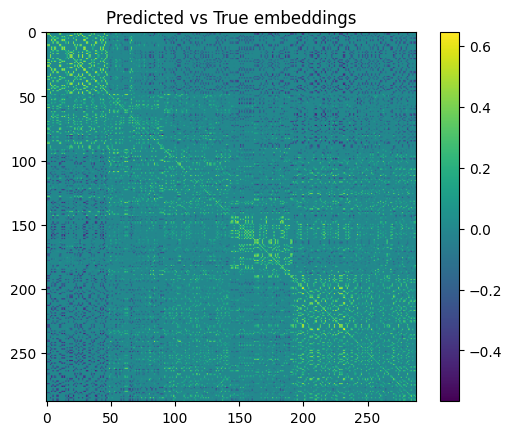

In [ ]:
plt.imshow(roi_mean_similarity_matrices['PT2hem'])
plt.colorbar()
plt.title("Predicted vs True embeddings")

## Semantic Category

In [111]:
import os
import re
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tqdm

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, balanced_accuracy_score
from sklearn.preprocessing import LabelEncoder


# =========================================================
# 1. HELPERS
# =========================================================

def extract_semantic_category(sound_name: str) -> str:
    """
    Esempi:
    'stim001_cat01_speech_exemp01' -> 'speech'
    'stim049_cat02_voice_exemp01'  -> 'voice'
    'stim145_cat04_music_exemp01'  -> 'music'
    """
    m = re.match(r"stim\d+_cat\d+_([a-zA-Z]+)_exemp\d+", str(sound_name))
    if m is None:
        raise ValueError(f"Formato inatteso per sound name: {sound_name}")
    return m.group(1).lower()


def average_test_by_sound(X_test, test_sounds):
    """
    Media X_test sui soggetti per ciascun suono test.
    Input:
        X_test: (n_subjects * 72, n_voxels)
        test_sounds: (n_subjects * 72,)
    Output:
        X_test_avg: (72, n_voxels)
        test_sounds_avg: (72,)
    """
    unique_sounds = np.unique(test_sounds)

    X_test_avg = []
    test_sounds_avg = []

    for s in unique_sounds:
        idx = np.where(test_sounds == s)[0]
        X_test_avg.append(X_test[idx].mean(axis=0))
        test_sounds_avg.append(s)

    X_test_avg = np.vstack(X_test_avg)
    test_sounds_avg = np.array(test_sounds_avg)

    return X_test_avg, test_sounds_avg


def zscore_train_test(X_train, X_test):
    train_mean = X_train.mean(axis=0, keepdims=True)
    train_std = X_train.std(axis=0, keepdims=True)
    train_std[train_std == 0] = 1.0

    X_train_z = (X_train - train_mean) / train_std
    X_test_z = (X_test - train_mean) / train_std

    return X_train_z, X_test_z, train_mean, train_std


def plot_roi_category_confusion(roi_mean_confusion_matrices, roi, class_names, figsize=(6, 5)):
    mat = roi_mean_confusion_matrices[roi]

    plt.figure(figsize=figsize)
    plt.imshow(mat, aspect="auto")
    plt.colorbar()
    plt.xticks(range(len(class_names)), class_names, rotation=45, ha="right")
    plt.yticks(range(len(class_names)), class_names)
    plt.xlabel("Predicted category")
    plt.ylabel("True category")
    plt.title(f"Mean semantic category confusion matrix | ROI={roi}")
    plt.tight_layout()
    plt.show()


# =========================================================
# 2. MAIN PIPELINE
# =========================================================

def evaluate_semantic_category_decoding(
    pooled_data,
    roi_list,
    cv_list,
    name_sounds,
    output_dir="./semantic_decoding_results",
    C=1.0,
    max_iter=3000,
):
    """
    Per ogni ROI e CV:
      - media il test sui soggetti
      - estrae le categorie semantiche dai nomi audio
      - allena un classificatore da fMRI -> semantic category
      - calcola accuracy, balanced accuracy, confusion matrix
      - media i risultati sui CV per ogni ROI

    Restituisce:
      roi_summary_df
      cv_results_df
      predictions_df
      roi_mean_confusion_matrices
      label_encoder
    """
    os.makedirs(output_dir, exist_ok=True)

    # -----------------------------------------------------
    # label globali da tutti i 288 suoni
    # -----------------------------------------------------
    semantic_labels_all = np.array([extract_semantic_category(x) for x in name_sounds])

    label_encoder = LabelEncoder()
    label_encoder.fit(semantic_labels_all)
    class_names = list(label_encoder.classes_)

    print("Semantic classes:", class_names)

    cv_rows = []
    prediction_rows = []

    # per ogni ROI accumulo confusion matrices dei CV
    roi_cv_confusions = {roi: [] for roi in roi_list}

    for roi in roi_list:
        print(f"\n================ ROI: {roi} ================\n")

        for cv in cv_list:
            if roi not in pooled_data or cv not in pooled_data[roi]:
                print(f"[SKIP] ROI={roi}, CV={cv} non presente in pooled_data.")
                continue

            entry = pooled_data[roi][cv]

            X_train_raw = np.asarray(entry["X_train"])
            X_test_raw = np.asarray(entry["X_test"])
            train_sounds = np.asarray(entry["train_sounds"]).astype(int).squeeze()
            test_sounds = np.asarray(entry["test_sounds"]).astype(int).squeeze()

            # media il test sui soggetti -> 72 sample
            X_test_avg, test_sounds_avg = average_test_by_sound(X_test_raw, test_sounds)

            # indici globali 0-based
            idx_train = train_sounds - 1
            idx_test = test_sounds_avg - 1

            # categorie semantiche
            y_train_str = semantic_labels_all[idx_train]
            y_test_str = semantic_labels_all[idx_test]

            y_train = label_encoder.transform(y_train_str)
            y_test = label_encoder.transform(y_test_str)

            # z-score fMRI
            X_train, X_test, _, _ = zscore_train_test(X_train_raw, X_test_avg)

            # classificatore
            clf = Pipeline([
                ("clf", LogisticRegression(
                    C=C,
                    max_iter=max_iter,
                    multi_class="multinomial",
                    solver="lbfgs",
                    class_weight="balanced",
                    n_jobs=None
                ))
            ])

            clf.fit(X_train, y_train)
            y_pred = clf.predict(X_test)

            if hasattr(clf.named_steps["clf"], "predict_proba"):
                y_proba = clf.predict_proba(X_test)
                confidence = np.max(y_proba, axis=1)
            else:
                confidence = np.full(len(y_pred), np.nan)

            acc = accuracy_score(y_test, y_pred)
            bacc = balanced_accuracy_score(y_test, y_pred)

            cm = confusion_matrix(
                y_test,
                y_pred,
                labels=np.arange(len(class_names)),
                normalize="true"
            )

            roi_cv_confusions[roi].append(cm)

            print(
                f"[ROI={roi} | CV={cv}] "
                f"X_train={X_train.shape}, X_test={X_test.shape}, "
                f"Acc={acc:.4f}, BalancedAcc={bacc:.4f}"
            )

            cv_rows.append({
                "roi": roi,
                "cv": cv,
                "n_train": X_train.shape[0],
                "n_test": X_test.shape[0],
                "n_voxels": X_train.shape[1],
                "accuracy": float(acc),
                "balanced_accuracy": float(bacc),
            })

            # salva predizioni sample-by-sample
            for i in range(len(idx_test)):
                prediction_rows.append({
                    "roi": roi,
                    "cv": cv,
                    "sample_local_idx": int(i),
                    "true_sound_idx_1based": int(idx_test[i] + 1),
                    "true_sound_name": str(name_sounds[idx_test[i]]),
                    "true_category": str(y_test_str[i]),
                    "pred_category": str(label_encoder.inverse_transform([y_pred[i]])[0]),
                    "correct": bool(y_pred[i] == y_test[i]),
                    "confidence": float(confidence[i]),
                })

    # -----------------------------------------------------
    # media sui CV per ROI
    # -----------------------------------------------------
    cv_results_df = pd.DataFrame(cv_rows)

    roi_summary_rows = []
    roi_mean_confusion_matrices = {}

    for roi in roi_list:
        roi_cv_df = cv_results_df[cv_results_df["roi"] == roi].copy()
        if len(roi_cv_df) == 0:
            continue

        roi_summary_rows.append({
            "roi": roi,
            "n_cvs": int(len(roi_cv_df)),
            "accuracy_mean": roi_cv_df["accuracy"].mean(),
            "accuracy_std": roi_cv_df["accuracy"].std(ddof=1) if len(roi_cv_df) > 1 else 0.0,
            "balanced_accuracy_mean": roi_cv_df["balanced_accuracy"].mean(),
            "balanced_accuracy_std": roi_cv_df["balanced_accuracy"].std(ddof=1) if len(roi_cv_df) > 1 else 0.0,
            "n_voxels_mean": roi_cv_df["n_voxels"].mean(),
        })

        if len(roi_cv_confusions[roi]) > 0:
            roi_mean_confusion_matrices[roi] = np.mean(
                np.stack(roi_cv_confusions[roi], axis=0),
                axis=0
            )

    roi_summary_df = pd.DataFrame(roi_summary_rows).sort_values(
        "balanced_accuracy_mean", ascending=False
    )
    predictions_df = pd.DataFrame(prediction_rows)

    # -----------------------------------------------------
    # salvataggi
    # -----------------------------------------------------
    # roi_summary_path = os.path.join(output_dir, "semantic_roi_summary_mean_over_cvs.csv")
    # cv_results_path = os.path.join(output_dir, "semantic_cv_results_all_rois.csv")
    # predictions_path = os.path.join(output_dir, "semantic_predictions_all_rois.csv")
    # confusions_path = os.path.join(output_dir, "semantic_roi_mean_confusion_matrices.pkl")

    # roi_summary_df.to_csv(roi_summary_path, index=False)
    # cv_results_df.to_csv(cv_results_path, index=False)
    # predictions_df.to_csv(predictions_path, index=False)

    # with open(confusions_path, "wb") as f:
    #     pickle.dump(roi_mean_confusion_matrices, f)

    # print("\n================ SAVED FILES ================\n")
    # print(roi_summary_path)
    # print(cv_results_path)
    # print(predictions_path)
    # print(confusions_path)

    return roi_summary_df, cv_results_df, predictions_df, roi_mean_confusion_matrices, label_encoder

In [112]:
semantic_roi_summary_df, semantic_cv_results_df, semantic_predictions_df, semantic_roi_mean_confusion_matrices, semantic_label_encoder = evaluate_semantic_category_decoding(
    pooled_data=pooled_data,
    roi_list=roi_list,
    cv_list=cv_list,
    name_sounds=name_sounds,
    output_dir="./semantic_decoding_results",
    C=1.0,
    max_iter=2000,
)

Semantic classes: ['animal', 'music', 'nature', 'speech', 'tools', 'voice']

================ ROI: HG2hem ================

[ROI=HG2hem | CV=CV1] X_train=(1080, 1024), X_test=(72, 1024), Acc=0.5694, BalancedAcc=0.5694
[ROI=HG2hem | CV=CV2] X_train=(1080, 1024), X_test=(72, 1024), Acc=0.6250, BalancedAcc=0.6250


/home/matteoc/miniconda3/envs/huggin/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/matteoc/miniconda3/envs/huggin/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/matteoc/miniconda3/envs/huggin/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


[ROI=HG2hem | CV=CV3] X_train=(1080, 1024), X_test=(72, 1024), Acc=0.5972, BalancedAcc=0.5972
[ROI=HG2hem | CV=CV4] X_train=(1080, 1024), X_test=(72, 1024), Acc=0.5694, BalancedAcc=0.5694

================ ROI: PT2hem ================

[ROI=PT2hem | CV=CV1] X_train=(1080, 1024), X_test=(72, 1024), Acc=0.6389, BalancedAcc=0.6389


/home/matteoc/miniconda3/envs/huggin/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/matteoc/miniconda3/envs/huggin/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/matteoc/miniconda3/envs/huggin/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


[ROI=PT2hem | CV=CV2] X_train=(1080, 1024), X_test=(72, 1024), Acc=0.7500, BalancedAcc=0.7500
[ROI=PT2hem | CV=CV3] X_train=(1080, 1024), X_test=(72, 1024), Acc=0.7361, BalancedAcc=0.7361


...

/home/matteoc/miniconda3/envs/huggin/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/matteoc/miniconda3/envs/huggin/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


[ROI=pSTG2hem | CV=CV4] X_train=(1080, 1024), X_test=(72, 1024), Acc=0.6806, BalancedAcc=0.6806

================ ROI: aSTG2hem ================

[ROI=aSTG2hem | CV=CV1] X_train=(1080, 1024), X_test=(72, 1024), Acc=0.6389, BalancedAcc=0.6389
[ROI=aSTG2hem | CV=CV2] X_train=(1080, 1024), X_test=(72, 1024), Acc=0.6389, BalancedAcc=0.6389


/home/matteoc/miniconda3/envs/huggin/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/matteoc/miniconda3/envs/huggin/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/matteoc/miniconda3/envs/huggin/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


[ROI=aSTG2hem | CV=CV3] X_train=(1080, 1024), X_test=(72, 1024), Acc=0.7222, BalancedAcc=0.7222
[ROI=aSTG2hem | CV=CV4] X_train=(1080, 1024), X_test=(72, 1024), Acc=0.6806, BalancedAcc=0.6806


/home/matteoc/miniconda3/envs/huggin/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [113]:
print(semantic_roi_summary_df)

        roi  n_cvs  accuracy_mean  accuracy_std  balanced_accuracy_mean  \
4  pSTG2hem      4       0.756944      0.056131                0.756944   
1    PT2hem      4       0.708333      0.049431                0.708333   
3  mSTG2hem      4       0.704861      0.055988                0.704861   
5  aSTG2hem      4       0.670139      0.039893                0.670139   
2    PP2hem      4       0.631944      0.080587                0.631944   
0    HG2hem      4       0.590278      0.026595                0.590278   

   balanced_accuracy_std  n_voxels_mean  
4               0.056131         1024.0  
1               0.049431         1024.0  
3               0.055988         1024.0  
5               0.039893         1024.0  
2               0.080587         1024.0  
0               0.026595         1024.0  


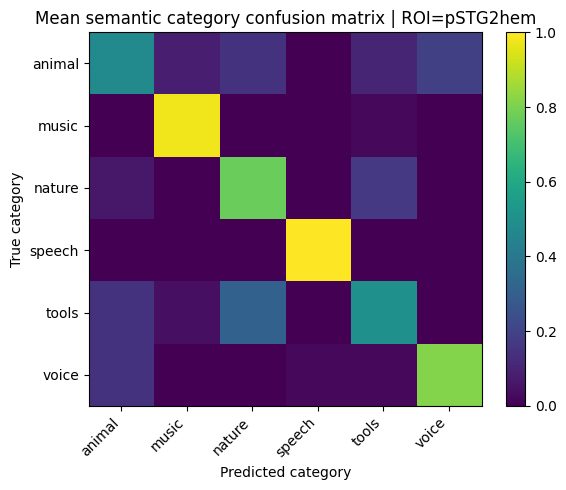

In [114]:
plot_roi_category_confusion(
    semantic_roi_mean_confusion_matrices,
    roi="pSTG2hem",
    class_names=semantic_label_encoder.classes_
)

## Stable Audio

In [124]:
from diffusers import StableAudioPipeline


@torch.no_grad()
def extract_stable_audio_conditioning(
    pipe: StableAudioPipeline,
    prompts,
    audio_start_in_s=0.0,
    audio_end_in_s=10.0,
    batch_size=8,
    device=None,
):
    """
    Restituisce:
      - raw_t5_hidden_states
      - attention_mask
      - projected_prompt_embeds
      - seconds_start_hidden_states
      - seconds_end_hidden_states
      - text_audio_duration_embeds
      - audio_duration_embeds
    """
    if device is None:
        device = pipe._execution_device if hasattr(pipe, "_execution_device") else pipe.device

    all_raw_t5 = []
    all_attn = []
    all_proj = []
    all_sec_start = []
    all_sec_end = []
    all_text_audio_duration = []
    all_audio_duration = []

    pipe.text_encoder.eval()
    pipe.projection_model.eval()

    for start in tqdm.tqdm(range(0, len(prompts), batch_size)):
        batch_prompts = prompts[start:start + batch_size]

        # 1) tokenizzazione
        text_inputs = pipe.tokenizer(
            batch_prompts,
            padding="max_length",
            max_length=pipe.tokenizer.model_max_length,
            truncation=True,
            return_tensors="pt",
        )
        input_ids = text_inputs.input_ids.to(device)
        attention_mask = text_inputs.attention_mask.to(device)

        # 2) T5 hidden states grezzi
        raw_t5_hidden = pipe.text_encoder(
            input_ids,
            attention_mask=attention_mask,
        )[0]  # [B, seq_len, hidden_dim]

        # 3) projected prompt embeds usati da Stable Audio
        projected_prompt_embeds = pipe.projection_model(
            text_hidden_states=raw_t5_hidden
        ).text_hidden_states

        projected_prompt_embeds = (
            projected_prompt_embeds * attention_mask.unsqueeze(-1).to(projected_prompt_embeds.dtype)
        )

        # 4) duration conditioning
        sec_start, sec_end = pipe.encode_duration(
            audio_start_in_s=audio_start_in_s,
            audio_end_in_s=audio_end_in_s,
            device=device,
            do_classifier_free_guidance=False,
            batch_size=len(batch_prompts),
        )

        # 5) conditioning finale che entra nel transformer
        text_audio_duration_embeds = torch.cat(
            [projected_prompt_embeds, sec_start, sec_end],
            dim=1
        )
        audio_duration_embeds = torch.cat([sec_start, sec_end], dim=2)

        all_raw_t5.append(raw_t5_hidden.cpu())
        all_attn.append(attention_mask.cpu())
        all_proj.append(projected_prompt_embeds.cpu())
        all_sec_start.append(sec_start.cpu())
        all_sec_end.append(sec_end.cpu())
        all_text_audio_duration.append(text_audio_duration_embeds.cpu())
        all_audio_duration.append(audio_duration_embeds.cpu())

    out = {
        "raw_t5_hidden_states": torch.cat(all_raw_t5, dim=0),
        "attention_mask": torch.cat(all_attn, dim=0),
        "projected_prompt_embeds": torch.cat(all_proj, dim=0),
        "seconds_start_hidden_states": torch.cat(all_sec_start, dim=0),
        "seconds_end_hidden_states": torch.cat(all_sec_end, dim=0),
        "text_audio_duration_embeds": torch.cat(all_text_audio_duration, dim=0),
        "audio_duration_embeds": torch.cat(all_audio_duration, dim=0),
    }
    return out

In [142]:
import torch
import torch.nn as nn


class BrainConditioner(nn.Module):
    def __init__(
        self,
        n_rois=6,
        roi_dim=1024,
        token_dim=768,
        n_heads=8,
        mlp_ratio=2.0,
        dropout=0.1,
    ):
        super().__init__()
        self.n_rois = n_rois
        self.roi_dim = roi_dim
        self.token_dim = token_dim

        # una proiezione per ROI
        self.roi_proj = nn.ModuleList([
            nn.Sequential(
                nn.LayerNorm(roi_dim),
                nn.Linear(roi_dim, token_dim),
                nn.GELU(),
                nn.Dropout(dropout),
                nn.Linear(token_dim, token_dim),
            )
            for _ in range(n_rois)
        ])

        # embedding identitario per ROI
        self.roi_embed = nn.Parameter(torch.randn(n_rois, token_dim) * 0.02)

        # piccolo mixing tra ROI
        self.attn = nn.MultiheadAttention(
            embed_dim=token_dim,
            num_heads=n_heads,
            dropout=dropout,
            batch_first=True
        )

        hidden_mlp = int(token_dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.LayerNorm(token_dim),
            nn.Linear(token_dim, hidden_mlp),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_mlp, token_dim),
        )

        self.norm1 = nn.LayerNorm(token_dim)
        self.norm2 = nn.LayerNorm(token_dim)

    def forward(self, x):
        """
        x: (B, 6, 1024)
        ritorna: (B, 6, 768)
        """
        tokens = []
        for i in range(self.n_rois):
            tok = self.roi_proj[i](x[:, i, :]) + self.roi_embed[i]
            tokens.append(tok)

        tokens = torch.stack(tokens, dim=1)  # (B, 6, 768)

        attn_out, attn_weights = self.attn(tokens, tokens, tokens, need_weights=True)
        tokens = self.norm1(tokens + attn_out)
        tokens = self.norm2(tokens + self.mlp(tokens))

        return tokens, attn_weights

In [143]:
from torch.utils.data import Dataset, DataLoader


class MultiROIDataset(Dataset):
    def __init__(self, X_roi, Y_text=None, y_cat=None):
        self.X_roi = torch.tensor(X_roi, dtype=torch.float32)
        self.Y_text = None if Y_text is None else torch.tensor(Y_text, dtype=torch.float32)
        self.y_cat = None if y_cat is None else torch.tensor(y_cat, dtype=torch.long)

    def __len__(self):
        return len(self.X_roi)

    def __getitem__(self, idx):
        item = {"x": self.X_roi[idx]}
        if self.Y_text is not None:
            item["y_text"] = self.Y_text[idx]
        if self.y_cat is not None:
            item["y_cat"] = self.y_cat[idx]
        return item

In [148]:
@torch.no_grad()
def extract_brain_tokens(model, X_roi, batch_size=64, device="cuda" if torch.cuda.is_available() else "cpu"):
    ds = MultiROIDataset(X_roi)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False)

    model.eval()
    all_tokens = []
    all_attn = []

    for batch in loader:
        x = batch["x"].to(device)
        _, tokens, attn = model(x)
        all_tokens.append(tokens.cpu().numpy())
        all_attn.append(attn.cpu().numpy())

    return np.concatenate(all_tokens, axis=0), np.concatenate(all_attn, axis=0)